In [23]:
import os
import glob
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



output_folder = '../../GREGoR_adaptive_sampling/'
manifest = pd.read_csv("../../adaptive_sampling_15.csv")
records = []

for sample_id in os.listdir(output_folder):
    sample_dir = os.path.join(output_folder, sample_id)
    # if not os.path.isdir(sample_dir):
    #     continue
    mosdepth_dirs = glob.glob(os.path.join(sample_dir, '*_mosdepth'))
    for mosdepth_dir in mosdepth_dirs:
        barcode = os.path.basename(mosdepth_dir).replace('_mosdepth', '')
        summary_files = glob.glob(os.path.join(mosdepth_dir, '*.mosdepth.summary.txt'))
        if not summary_files:
            continue
        summary_file = summary_files[0]
        # Read file and only keep total/total_region
        df = pd.read_csv(summary_file, sep='\t')
        df = df[df['chrom'].isin(['total', 'total_region'])]
        df['sample_id'] = sample_id
        df['barcode'] = barcode
        records.append(df)

# Combine all records
if records:
    final_df = pd.concat(records, ignore_index=True)
else:
    final_df = pd.DataFrame()
final_df['bed_file'] = final_df['sample_id'].map(dict(zip(manifest['sample_id'], manifest['bed_file'])))
# import numpy as np
final_df['barcode_status'] = np.where(final_df['barcode'].str.contains('unassigned', case=False, na=False),
                                       'unassigned', 'with_barcode')

plot_df = final_df[final_df['chrom'].isin(['total', 'total_region'])].copy()
df = plot_df[(plot_df.chrom == "total_region") & (plot_df.barcode_status == "with_barcode")].copy()
bed_file_order = df['bed_file'].drop_duplicates().sort_values().tolist()
df['bed_file'] = pd.Categorical(df['bed_file'], categories=bed_file_order, ordered=True)
df = df.sort_values(['bed_file', 'sample_id'])
sample_order = df['sample_id'].unique()

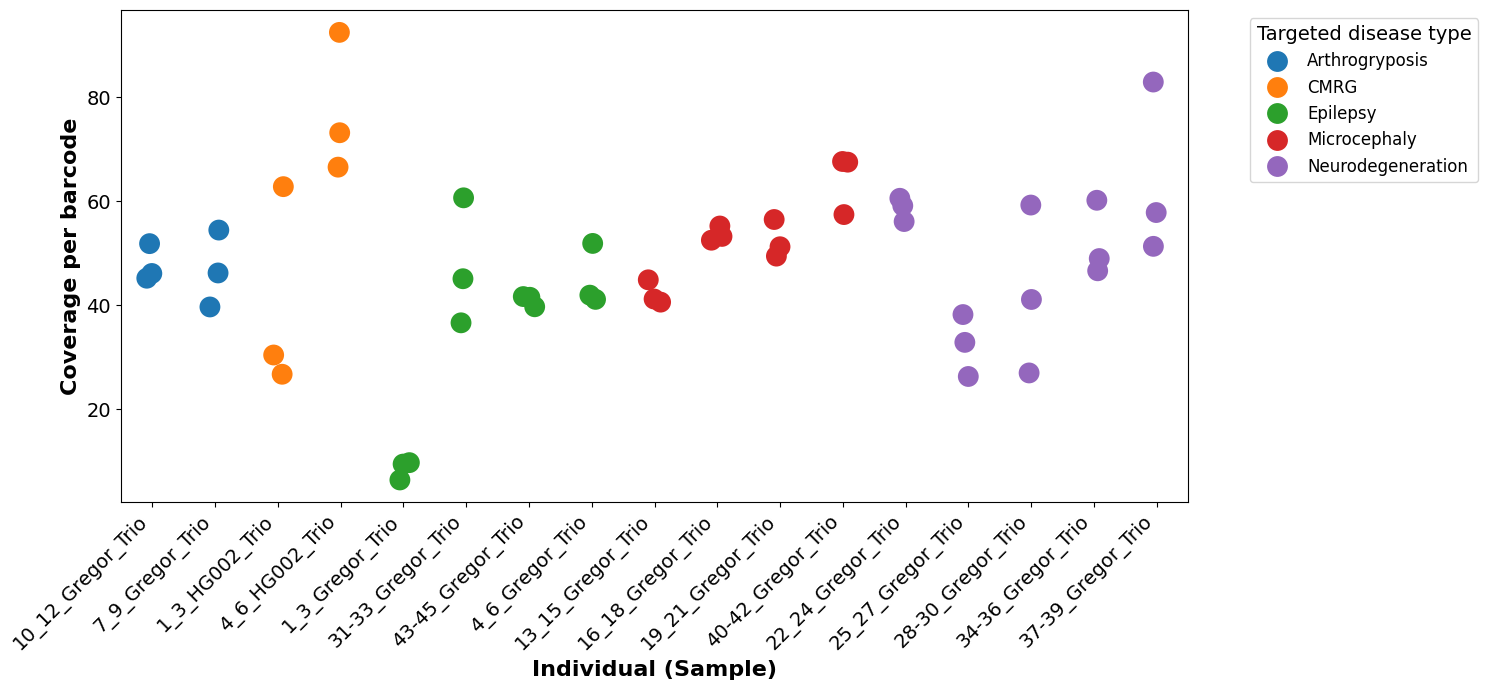

In [26]:
plt.figure(figsize=(15, 7))
ax = sns.stripplot(
    data=df,
    x='sample_id',
    y='mean',
    hue='bed_file',
    dodge=False,
    size=15,
    jitter=True,
    order=sample_order,
    palette='tab10'
)

plt.xticks(rotation=45, ha='right', fontsize=14)   # x-axis tick labels
plt.yticks(fontsize=14)                            # y-axis tick labels
plt.xlabel("Individual (Sample)", fontsize=16, fontweight='bold')
plt.ylabel("Coverage per barcode", fontsize=16, fontweight='bold')
# plt.title("Coverage per Individual ...", fontsize=18, fontweight='bold')

plt.legend(
    title="Targeted disease type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=12,           # legend labels
    title_fontsize=14      # legend title
)

plt.tight_layout()
plt.show()


In [19]:
bed_coverage_dict = {
    "Arthrogryposis": "../../analysis/covearge/Arthro_2582_padded_top11_manual_annotated.sorted.merged.bed.coverage.txt",
    "Epilepsy": "../../analysis/covearge/Epilepsy_V2_1662_padded_top8_manual_annotated.sorted.merged.bed.coverage.txt",
    "Microcephaly": "../../analysis/covearge/Microcephaly_1769_padded_top3_manual_annotated.sorted.merged.bed.coverage.txt",
    "Neurodegeneration": "../../analysis/covearge/Neurodegen_V2_1704_padded_top8_manual_annotated.sorted.merged.bed.coverage.txt",
    "CMRG": "../../analysis/covearge/GRCh38_CMRG_benchmark_gene_coordinates_padding10K.bed.coverage.txt",
}

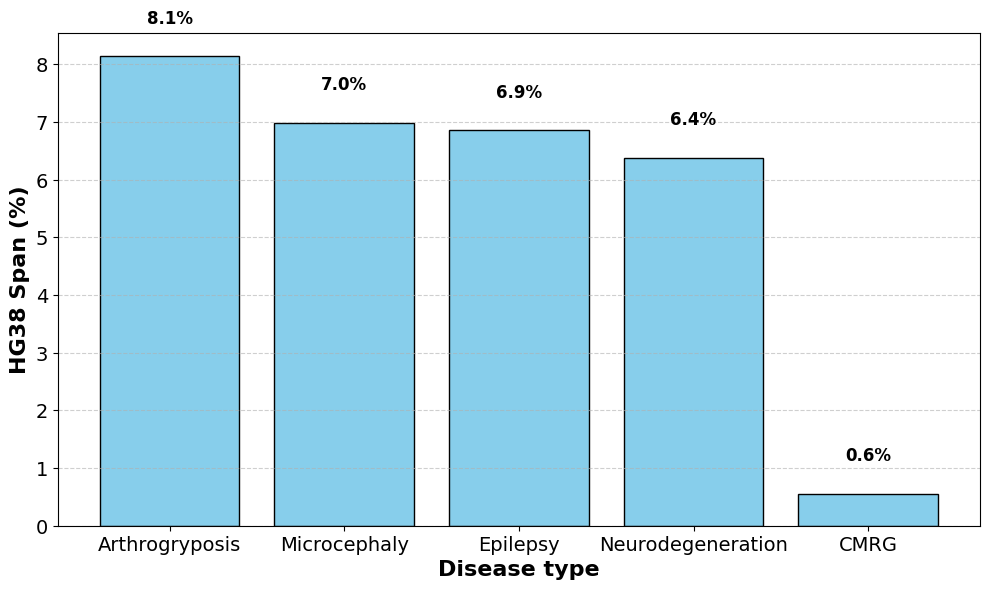

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect genome 1 coverage values
coverage_data = []

for index, coverage_file in bed_coverage_dict.items():
    with open(coverage_file) as f:
        for line in f:
            if line.startswith("genome") and line.split()[1] == "1":
                coverage = float(line.strip().split()[-1]) * 100  # convert to percent
                coverage_data.append({"Sample": index, "Genome1_Coverage (%)": coverage})
                break

# Create a DataFrame
coverage_df = pd.DataFrame(coverage_data)

# Sort by coverage if desired
coverage_df.sort_values("Genome1_Coverage (%)", ascending=False, inplace=True)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(
    coverage_df["Sample"],
    coverage_df["Genome1_Coverage (%)"],
    color="skyblue",
    edgecolor="black"
)

# Add labels with bigger font sizes
plt.ylabel("HG38 Span (%)", fontsize=16, fontweight='bold')
plt.xlabel("Disease type", fontsize=16, fontweight='bold')
# plt.title("HG38 Genome1 Coverage", fontsize=18, fontweight='bold')
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=12,   # larger percentage labels
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


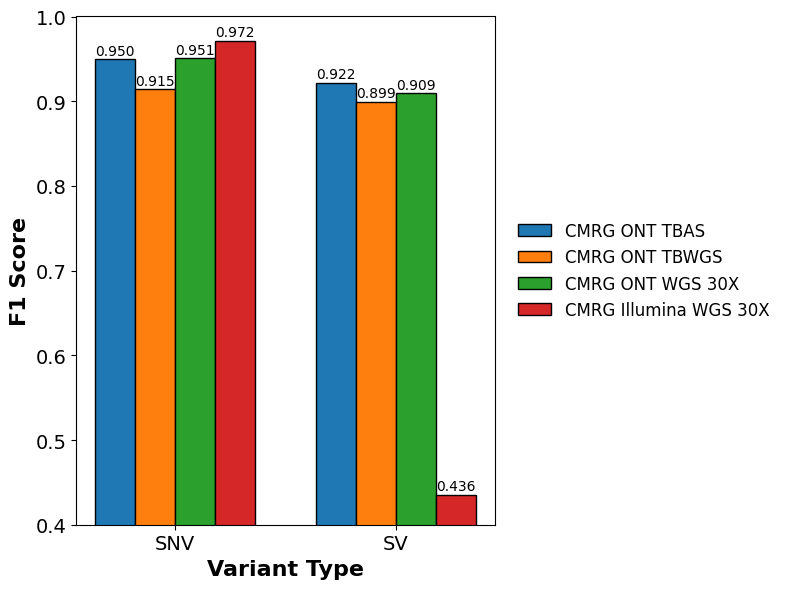

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
# mpl.rcParams.update(mpl.rcParamsDefault)

# Data
data = {
    "F1 score": ["SNV", "SV"],
    "CMRG ONT TBAS": [0.9495, 0.9219],
    "CMRG ONT TBWGS": [0.9147, 0.8995], 
    "CMRG ONT WGS 30X": [0.9512, 0.9091], 
    "CMRG Illumina WGS 30X": [0.9716, 0.4356], 
}
df = pd.DataFrame(data)

# Melt into long format
df_long = df.melt(id_vars="F1 score", var_name="Method", value_name="F1")

# Setup
methods = df_long["Method"].unique()
x = np.arange(len(df["F1 score"]))
bar_width = 0.18

plt.figure(figsize=(8, 6))

# Plot
for i, method in enumerate(methods):
    vals = df_long[df_long["Method"] == method]["F1"]
    plt.bar(
        x + i*bar_width - (len(methods)-1)/2*bar_width,
        vals,
        width=bar_width,
        label=method,
        edgecolor="black"
    )
    # Add labels
    for j, v in enumerate(vals):
        plt.text(
            x[j] + i*bar_width - (len(methods)-1)/2*bar_width,
            v + 0.005,
            f"{v:.3f}",
            ha="center",
            fontsize=10
        )

# Formatting
plt.xticks(x, df["F1 score"], fontsize=14)
plt.ylabel("F1 Score", fontsize=16, fontweight="bold")
plt.xlabel("Variant Type", fontsize=16, fontweight="bold")
plt.ylim(0.4, 1.0)
plt.yticks(fontsize=14)

# Legend outside
plt.legend(
    fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()


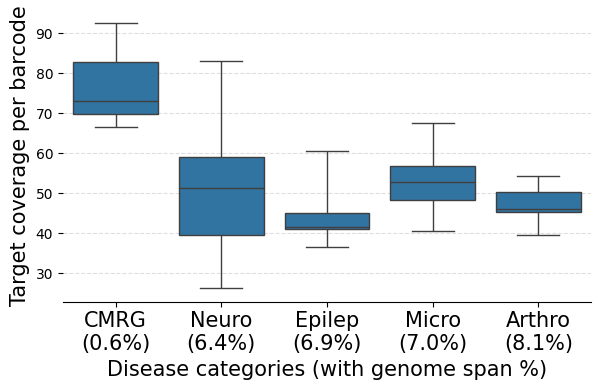

In [37]:
# --- 1) Ensure final_df has a 'bed_file' column mapped from the manifest, no matter what the manifest calls it ---
import os
import numpy as np
import pandas as pd

drop_ids = ['1_3_HG002_Trio', '1_3_Gregor_Trio']
man = manifest[~manifest['sample_id'].isin(drop_ids)]
man.columns = [c.strip().lower() for c in man.columns]

# Find sample_id-like column
sample_col = next((c for c in man.columns if c in ["sample_id", "sample", "id", "sampleid"]), None)
if sample_col is None:
    raise ValueError(f"Couldn't find a sample_id column in manifest. Columns: {list(man.columns)}")

# Find a bed-like column
bed_like_cols = [c for c in man.columns if any(k in c for k in ["bed", "panel", "disease", "target", "assay", "design", "phenotype"])]
if not bed_like_cols:
    raise ValueError(f"Couldn't find a column describing the BED/panel/disease in manifest. Columns: {list(man.columns)}")
bed_col = bed_like_cols[0]

# Build initial map: sample_id -> raw bed label/value
sample_to_bed_raw = dict(zip(man[sample_col].astype(str), man[bed_col].astype(str)))

# Normalization: map raw values (file paths / names) to the canonical keys in bed_coverage_dict
canonical_keys = list(bed_coverage_dict.keys())
keyword_map = {
    "arthro": "Arthrogryposis",
    "epilep": "Epilepsy",
    "micro": "Microcephaly",
    "neuro": "Neurodegeneration",
    "cmrg": "CMRG",
}

def normalize_to_canonical_bed(value: str) -> str | float:
    if pd.isna(value):
        return np.nan
    s = str(value)
    base = os.path.basename(s).lower()
    # direct match
    for k in canonical_keys:
        if s == k or s.lower() == k.lower():
            return k
    # substring match to canonical keys
    for k in canonical_keys:
        if k.lower() in base:
            return k
    # keyword fallback
    for kw, label in keyword_map.items():
        if kw in base:
            return label
    # if it's already a canonical key present in dict, keep it; else NaN
    return s if s in bed_coverage_dict else np.nan

# Attach normalized bed_file to final_df using sample_id
final_df['sample_id'] = final_df['sample_id'].astype(str)
final_df['bed_file'] = final_df['sample_id'].map(sample_to_bed_raw).map(normalize_to_canonical_bed)

# --- 2) Build BED span (%) table from your coverage summaries ---
bed_span_rows = []
for bed_name, coverage_file in bed_coverage_dict.items():
    with open(coverage_file) as f:
        for line in f:
            parts = line.split()
            if parts and parts[0] == "genome" and parts[1] == "1":
                span_pct = float(parts[-1]) * 100.0  # to %
                bed_span_rows.append({"bed_file": bed_name, "BED span (%)": span_pct})
                break

bed_span_df = pd.DataFrame(bed_span_rows)

# --- 3) Filter to targeted regions + valid barcodes, merge span, and plot (one plot!) ---
plot_df = final_df.copy()
plot_df = plot_df[(plot_df['chrom'] == 'total_region') & (plot_df['barcode_status'] == 'with_barcode')].copy()
plot_df = plot_df.dropna(subset=['bed_file'])
plot_df = plot_df.merge(bed_span_df, on='bed_file', how='left')
plot_df = plot_df.dropna(subset=['BED span (%)', 'mean'])

# Optional: order beds by span
bed_order = (
    plot_df[['bed_file', 'BED span (%)']]
    .drop_duplicates()
    .sort_values('BED span (%)')
    .bed_file.tolist()
)
plot_df['bed_file'] = pd.Categorical(plot_df['bed_file'], categories=bed_order, ordered=True)
plot_df['mean'] = pd.to_numeric(plot_df['mean'], errors='coerce')
plot_df = plot_df.dropna(subset=['mean'])

# Get ordering of bed files by span
bed_span_map = dict(zip(bed_span_df['bed_file'], bed_span_df['BED span (%)']))
bed_order = (
    plot_df[['bed_file']]
    .drop_duplicates()
    .assign(span=lambda d: d['bed_file'].map(bed_span_map))
    .sort_values('span')['bed_file']
    .tolist()
)
abbr_map = {
    "Arthrogryposis": "Arthro",
    "Epilepsy": "Epilep",
    "Microcephaly": "Micro",
    "Neurodegeneration": "Neuro",
    "CMRG": "CMRG",
}

# Annotated labels: name + span
xtick_labels = [
    f"{abbr_map.get(b, b)}\n({bed_span_map[b]:.1f}%)"
    for b in bed_order
]

g = sns.catplot(
    data=plot_df,
    x="bed_file",
    y="mean",
    kind="box",
    order=bed_order,
    height=4,
    aspect=1.5,
    whis=[0, 100],              # extend whiskers to min/max
    flierprops=dict(marker='')  # don't plot outlier dots
)
# Update labels
g.set_axis_labels(
    "Disease categories (with genome span %)", 
    "Target coverage per barcode", fontsize=15
)
g.set_xticklabels(xtick_labels, rotation=0, ha="center", fontsize=15)

# Grid and formatting
g.set_titles("")
g.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("../../paper_figures/covearge.pdf")


In [ ]:
fontsize